Adaptive Backward Euler Results
t		y
0.000000	1.000000
0.000391	0.996482
0.000781	0.992962
0.001172	0.989439
0.001563	0.985913
0.001953	0.982384
0.002344	0.978853
0.002734	0.975319
0.003125	0.971782
0.003516	0.968243
0.003906	0.964701
0.004297	0.961156
0.004687	0.957609
0.005078	0.954059
0.005469	0.950506
0.005859	0.946951
0.006250	0.943393
0.006641	0.939832
0.007031	0.936269
0.007422	0.932703
0.007813	0.929135
0.008203	0.925564
0.008594	0.921990
0.008984	0.918414
0.009375	0.914836
0.009766	0.911254
0.010156	0.907671
0.010547	0.904084
0.010938	0.900495
0.011328	0.896904
0.011719	0.893310
0.012109	0.889714
0.012500	0.886115
0.012891	0.882513
0.013281	0.878910
0.013672	0.875303
0.014063	0.871694
0.014453	0.868083
0.014844	0.864469
0.015234	0.860853
0.015625	0.857235
0.016016	0.853614
0.016406	0.849990
0.016797	0.846364
0.017188	0.842736
0.017578	0.839105
0.017969	0.835472
0.018359	0.831837
0.018750	0.828199
0.019141	0.824559
0.019531	0.820917
0.019922	0.817272
0.020312	0.813625
0.020703	

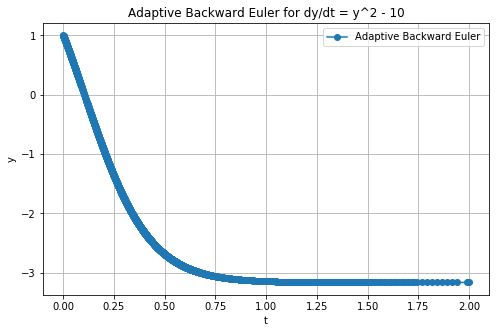

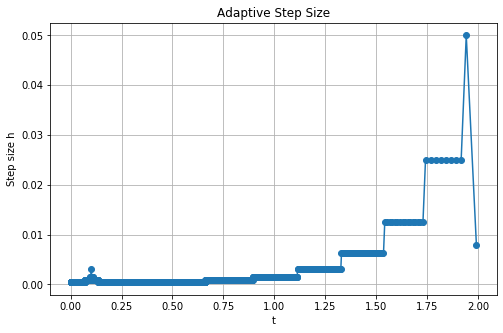

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize and check this code.

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2*y

# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y

    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)

        if abs(g_prime_val) < tol:
            break

        y_new = y_next - g_val / g_prime_val

        if abs(y_new - y_next) < tol:
            return y_new

        y_next = y_new

    return y_next

# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]

    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        # One full step with h
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        # Two half steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        # Error estimation
        error = abs(y_full - y_half_2)

        # Adjust step size
        if error > tol:
            h = h / 2
            continue
        elif error < tol / 2:
            h = h * 2

        # Accept the step
        t = t + h_half * 2
        y = y_half_2

        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

# Initial values
y0 = 1
t0 = 0
tf = 2
h_init = 0.1

t_vals, y_vals = backward_euler_adaptive(f, y0, t0, tf, h_init)

print("Adaptive Backward Euler Results")
print("t\t\ty")
for i in range(len(t_vals)):
    print(f"{t_vals[i]:.6f}\t{y_vals[i]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(t_vals, y_vals, marker='o', label="Adaptive Backward Euler")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler for dy/dt = y^2 - 10")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_vals[:-1], np.diff(t_vals), marker='o')
plt.xlabel("t")
plt.ylabel("Step size h")
plt.title("Adaptive Step Size")
plt.grid(True)
plt.show()